# Auto ML e Resultados

| Biblioteca  | Abordagem principal                  | Saída principal            | Observação prática  |
| ----------- | ------------------------------------ | -------------------------- | ------------------- |
| TPOT        | Algoritmo genético                   | Pipeline do scikit-learn   | Pesado              |
| H2O AutoML  | Treinamento de vários modelos        | Melhor modelo + ranking    | Exige Java          |
| AutoSklearn | Meta-learning + otimização bayesiana | Modelo/ensemble automático | Não roda em windows |

## Dataset 
- Regressão
- Resistência do concreto:
	- Quantidade de cimento;
	- Água
	- Idade do concreto


## h2o
   Documentacao (Boa) - https://docs.h2o.ai/h2o/latest-stable/h2o-docs/index.html
   Tem que ter Java compiler 

h2o - doc:
   python 3.11 e numpy < 2 

1. Treina modelos básicos rápidos  (lista de modelos)
2. Treina modelos mais fortes  
3. Testa variações de alguns modelos - busca de hiperparâmetros em algumas famílias  
4. Compara tudo no leaderboard  
5. Testa variações de alguns modelos - busca de hiperparâmetros em algumas famílias  
6. Atualiza o leaderboard  
7. Quando já tem modelos suficientes, tenta combinar os melhores usando **Stacked Ensemble**.

Internamente tem uma lista de hiperparâmetros que vale a pena variar para cada tipo de modelo, segue espaços de busca pré-definidos e vai sorteando/testando combinações dentro desses espaços.

Não retorna diretamente os hyperparametros, da para salvar os modelos treinados ao longo do processo.

```python
import h2o
from h2o.automl import H2OAutoML, get_leaderboard

# so iniciamos
h20.init(
        max_mem_size=
        nthreads=
        ice_root= pasta temporária
        log_dir= pasta logs
        verbose= mostrar inicilizacao
)
df = h2o.H2OFrame(pd.DataFrame)

ml = h20.H2OAutoML(
            max_runtime_secs= 
            max_models=           
            max_runtime_secs_per_model=
            nfolds= folds cv 
            stopping_metric=
            sort_metric= criterio ordem leaderboard
            stopping_rounds= rodadas sem melhorar
            stopping_tolerance= porcetagem de melhora necessaria 
            seed=
            verbosity= niver de log terminal
            export_checkpoints_dir= 
            project_name=

        )
aml.train(x=x_cols, y=target_name, training_frame=df)
leaderboard = get_leaderboard(aml, extra_columns=str) 

m = h2o.get_model(model_id)
m = h2o.load_model(path)

```


## tpot 
    
Documentação (Fraca) - https://epistasislab.github.io/tpot/latest/

TPOT paper - https://www.sciencedirect.com/science/article/pii/S266638992500162X

TPOT2 paper -  https://doi.org/10.1007/978-981-99-8413-8_1
### **Mudancas TPOT1 -> TPOT2**
**Árvore → Grafo**
	TPOT1 - pipelines como árvores
	TPOT2 - usa grafos acíclicos direcionados, permitindo pipelines mais flexíveis.

**Template → Search Space**
	Restringe quais tipos de pipelines, modelos e etapas ele pode explorar

**DEAP → módulo próprio**

1) TPOT cria vários pipelines candidatos  
2) Avalia cada pipeline com cross-validation
3) Escolhe os melhores
4) Gera novos pipelines por mutação e crossover
5) Repete por várias gerações
6) Retorna o melhor pipeline encontrado

```python 
search = TPOTRegressor(
	search_space=
	scorers=
	scorers_weights=
	preprocessing= bool 
	validation_strategy= "cv"
	verbose= nivel de log terminal
	random_state= seed 
	generations=
	population_size=
	max_eval_time_mins=
	early_stop= numero de geracoes sem melhora
	cv=
	n_jobs= numero núcleos
	processes= numero threads paralelas
	mutate_probability=
	crossover_probability= 
	periodic_checkpoint_folder=
    )

    search.fit(X, y)
    best_pipeline = search.fitted_pipeline_
    historico = search.evaluated_individuals

### Problemas:
	Dependencias extras Java e Docker (para windows)
Interpretacao de erro (tpot), cometi um erro no data set de deixar a data em formato de data.

In [37]:
from pathlib import Path
import json
import math
import sys

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from io import StringIO
from IPython.display import display, Markdown

try:
    from dengue_prediction.settings import DATA_DIR
    DATA_DIR = Path(DATA_DIR)
except Exception:
    cwd = Path.cwd().resolve()
    project_root = next(
        (p for p in [cwd, *cwd.parents] if (p / "dengue_prediction" / "data").exists()),
        cwd.parent if cwd.name == "notebooks" else cwd,
    )
    src_dir = project_root / "dengue_prediction" / "src"
    if src_dir.exists() and str(src_dir) not in sys.path:
        sys.path.insert(0, str(src_dir))
    try:
        from dengue_prediction.settings import DATA_DIR
        DATA_DIR = Path(DATA_DIR)
    except Exception:
        DATA_DIR = project_root / "dengue_prediction" / "data"

AUTOML_DIR = DATA_DIR / "results" / "autoML"
pd.set_option("display.max_colwidth", 120)

print(f"DATA_DIR: {DATA_DIR}")
print(f"Resultados AutoML: {AUTOML_DIR}")

DATA_DIR: C:\Users\pedro\DEV\dengue_prediction\dengue_prediction\data
Resultados AutoML: C:\Users\pedro\DEV\dengue_prediction\dengue_prediction\data\results\autoML


## Funcoes de leitura

In [38]:
def carregar_json(path):
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)


def listar_runs(framework):
    base_dir = AUTOML_DIR / framework
    if not base_dir.exists():
        print(f"Sem pasta de resultados para {framework}: {base_dir}")
        return []
    return sorted([p for p in base_dir.iterdir() if p.is_dir()], key=lambda p: p.name, reverse=True)


def carregar_search_history(run_dir):
    csv_path = run_dir / "search_history.csv"
    json_path = run_dir / "search_history.json"

    if csv_path.exists():
        try:
            return pd.read_csv(csv_path)
        except Exception as exc:
            print(f"Não foi possível ler {csv_path.name}: {exc}")

    if json_path.exists():
        try:
            data = carregar_json(json_path)

            if isinstance(data, list):
                return pd.DataFrame(data)

            if isinstance(data, dict):
                if "search_history" in data:
                    data = data["search_history"]
                else:
                    return pd.DataFrame(data)

            if isinstance(data, str):
                texto = data.strip()

                # Remove linhas tipo "[45 rows x 9 columns]"
                linhas = [
                    linha for linha in texto.splitlines()
                    if not linha.strip().startswith("[")
                ]

                texto_limpo = "\n".join(linhas)

                try:
                    df = pd.read_fwf(StringIO(texto_limpo))
                    return df
                except Exception as exc:
                    print(f"Não foi possível converter tabela em texto: {exc}")
                    print(texto[:1000])
                    return pd.DataFrame()

        except Exception as exc:
            print(f"Não foi possível ler {json_path.name}: {exc}")

    print(f"Sem search_history em {run_dir.name}")
    return pd.DataFrame()

def carregar_run(framework, run_dir):
    def ler_se_existir(nome):
        path = run_dir / nome
        if not path.exists():
            print(f"Arquivo ausente: {path}")
            return {}
        try:
            return carregar_json(path)
        except Exception as exc:
            print(f"Nao foi possivel ler {nome}: {exc}")
            return {}

    return {
        "framework": framework,
        "run_id": run_dir.name,
        "run_dir": run_dir,
        "metadata": ler_se_existir("metadata.json"),
        "best_model": ler_se_existir("best_model.json"),
        "report": ler_se_existir("report.json"),
        "search_history": carregar_search_history(run_dir),
    }

## Runs disponiveis

Por padrao, o notebook usa a run mais recente. Para escolher outra, preencha `h2o_run_id` ou `tpot_run_id` com o nome da pasta da run.

In [39]:
h2o_runs = listar_runs("h2o")
tpot_runs = listar_runs("tpot")

display(pd.DataFrame({"h2o_runs": [p.name for p in h2o_runs]}))
display(pd.DataFrame({"tpot_runs": [p.name for p in tpot_runs]}))

runs = []

for h2o_run_dir in h2o_runs:
    if h2o_run_dir.exists():
        runs.append(carregar_run("h2o", h2o_run_dir))

for tpot_run_dir in tpot_runs:
    if tpot_run_dir.exists():
        runs.append(carregar_run("tpot", tpot_run_dir))

print("Runs carregadas:")
for r in runs:
    print(f"{r['framework']}:{r['run_id']}")

print(f"\nTotal de runs carregadas: {len(runs)}")

,h2o_runs
0,20260430T172657Z


,tpot_runs
0,20260430T150932Z


Não foi possível ler search_history.csv: No columns to parse from file
Runs carregadas:
h2o:20260430T172657Z
tpot:20260430T150932Z

Total de runs carregadas: 2


## Comparacao geral

In [40]:
def primeiro_numero(valor):
    if valor is None:
        return None
    try:
        if pd.isna(valor):
            return None
    except Exception:
        pass
    if isinstance(valor, (int, float, np.number)):
        return float(valor)

    texto = str(valor).replace(",", ".")
    achados = pd.Series(texto).str.extract(
        r"([-+]?\d*\.?\d+(?:[eE][-+]?\d+)?)"
    ).iloc[0, 0]

    return float(achados) if pd.notna(achados) else None


def coluna_score_tpot(df):
    if "root_mean_squared_error" in df.columns:
        return "root_mean_squared_error"
    if "neg_root_mean_squared_error" in df.columns:
        return "neg_root_mean_squared_error"
    return None


def rmse_tpot(df, raw_value=None):
    col = coluna_score_tpot(df)

    if col:
        valores = pd.to_numeric(df[col], errors="coerce").dropna()

        if not valores.empty:
            # Como o TPOT usa métrica negativa:
            # -23 é melhor que -30
            melhor_score = valores.max()
            return col, abs(float(melhor_score))

    # fallback: usa o valor salvo no best_model["score"]["value"]
    if raw_value is not None:
        return col, abs(float(raw_value))

    return col, None


def extrair_resumo(run_data):
    metadata = run_data.get("metadata", {}) or {}
    best_model = run_data.get("best_model", {}) or {}
    score = best_model.get("score", {}) or {}

    raw_metric = score.get("metric") or metadata.get("optimization_metric")
    raw_value = primeiro_numero(score.get("value"))

    comparable_metric = None
    comparable_score = None

    if run_data["framework"] == "h2o":
        metric = str(raw_metric or "").lower()

        if raw_value is not None and metric == "rmse":
            comparable_metric = "RMSE"
            comparable_score = raw_value

        elif raw_value is not None and metric == "mse":
            comparable_metric = "RMSE"
            comparable_score = math.sqrt(raw_value)

    elif run_data["framework"] == "tpot":
        search_history = run_data.get("search_history", pd.DataFrame())

        score_col, comparable_score = rmse_tpot(
            search_history,
            raw_value=raw_value
        )

        comparable_metric = "RMSE" if comparable_score is not None else None
        raw_metric = raw_metric or score_col

    tempo_seg = primeiro_numero(metadata.get("training_time_seconds"))

    return {
        "framework": run_data.get("framework"),
        "run_id": run_data.get("run_id"),
        "preset": metadata.get("preset"),
        "optimization_metric": metadata.get("optimization_metric"),
        "training_time_seconds": tempo_seg,
        "training_time_minutes": tempo_seg / 60 if tempo_seg is not None else None,
        "raw_score_metric": raw_metric,
        "raw_score_value": raw_value,
        "comparable_metric": comparable_metric,
        "comparable_score": comparable_score,
        "best_model_name": best_model.get("model_name"),
        "best_model_family": best_model.get("model_family"),
        "output_dir": metadata.get("output_dir") or str(run_data.get("run_dir")),
    }


resumo_df = pd.DataFrame([extrair_resumo(run) for run in runs])

if resumo_df.empty:
    print("Nenhuma run encontrada para comparar.")
else:
    resumo_view = resumo_df.sort_values("comparable_score", na_position="last")

    display(resumo_view[[
        "framework",
        "run_id",
        "preset",
        "optimization_metric",
        "training_time_minutes",
        "raw_score_metric",
        "raw_score_value",
        "comparable_metric",
        "comparable_score",
        "best_model_family",
        "best_model_name"
    ]])

,framework,run_id,preset,optimization_metric,training_time_minutes,raw_score_metric,raw_score_value,comparable_metric,comparable_score,best_model_family,best_model_name
0,h2o,20260430T172657Z,medium,RMSE,19.878608,RMSE,3.620265,RMSE,3.620265,StackedEnsemble,StackedEnsemble_AllModels_1_AutoML_1_20260430_142724
1,tpot,20260430T150932Z,medium,neg_root_mean_squared_error,25.756541,neg_root_mean_squared_error,-4.939356,RMSE,4.939356,LGBMRegressor,"Pipeline(steps=[('standardscaler', StandardScaler()),\n ('selectfrommodel',\n SelectF..."


## Graficos comparativos

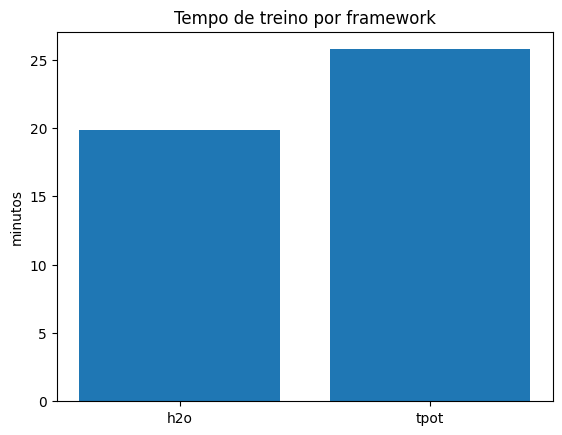

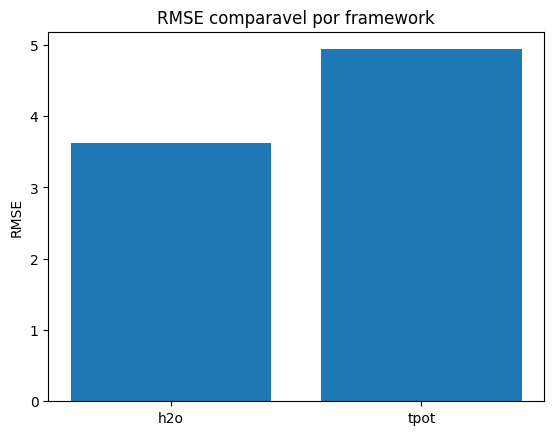

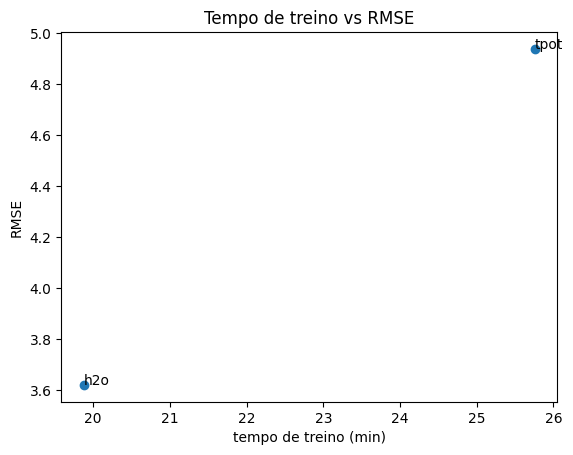

In [41]:
if not resumo_df.empty and resumo_df["training_time_minutes"].notna().any():
    plot_df = resumo_df.dropna(subset=["training_time_minutes"])
    plt.figure()
    plt.bar(plot_df["framework"], plot_df["training_time_minutes"])
    plt.ylabel("minutos")
    plt.title("Tempo de treino por framework")
    plt.show()
else:
    print("Sem tempo de treino para plotar.")

if not resumo_df.empty and resumo_df["comparable_score"].notna().any():
    plot_df = resumo_df.dropna(subset=["comparable_score"])
    plt.figure()
    plt.bar(plot_df["framework"], plot_df["comparable_score"])
    plt.ylabel("RMSE")
    plt.title("RMSE comparavel por framework")
    plt.show()
else:
    print("Sem RMSE comparavel para plotar.")

if not resumo_df.empty and resumo_df[["training_time_minutes", "comparable_score"]].notna().all(axis=1).any():
    plot_df = resumo_df.dropna(subset=["training_time_minutes", "comparable_score"])
    plt.figure()
    plt.scatter(plot_df["training_time_minutes"], plot_df["comparable_score"])
    for _, row in plot_df.iterrows():
        plt.annotate(row["framework"], (row["training_time_minutes"], row["comparable_score"]))
    plt.xlabel("tempo de treino (min)")
    plt.ylabel("RMSE")
    plt.title("Tempo de treino vs RMSE")
    plt.show()
else:
    print("Sem dados suficientes para scatter de tempo vs RMSE.")

## Analise H2O AutoML

O H2O AutoML tende a testar diferentes familias de modelos, como GLM, GBM, DRF/XRT e DeepLearning, alem de criar Stacked Ensembles no final. A ordem pode ser observada no `training_info` e o desempenho final pode ser observado no leaderboard.

Resumo H2O AutoML


,framework,run_id,preset,métrica,tempo_total_min,total_modelos_testados,melhor_modelo,familia_melhor_modelo,score
0,H2O AutoML,20260430T172657Z,medium,RMSE,19.878608,37,StackedEnsemble_AllModels_1_AutoML_1_20260430_142724,StackedEnsemble,3.620265


Top 10 modelos do leaderboard


,model_id,algo,rmse,mse,mae,training_time_ms,predict_time_per_row_ms
0,StackedEnsemble_AllModels_1_AutoML_1_20260430_142724,StackedEnsemble,3.620265,13.106320,2.264196,669,0.191210
1,StackedEnsemble_BestOfFamily_1_AutoML_1_20260430_142724,StackedEnsemble,3.719759,13.836610,2.381889,510,0.058976
2,GBM_grid_1_AutoML_1_20260430_142724_model_2,GBM,3.726460,13.886508,2.369759,1004,0.050887
3,GBM_3_AutoML_1_20260430_142724,GBM,3.728266,13.899966,2.329842,1196,0.055387
4,GBM_grid_1_AutoML_1_20260430_142724_model_10,GBM,3.729579,13.909759,2.386557,1073,0.067882
5,GBM_4_AutoML_1_20260430_142724,GBM,3.753462,14.088476,2.310092,1310,0.063565
6,GBM_grid_1_AutoML_1_20260430_142724_model_11,GBM,3.770742,14.218495,2.420806,919,0.047359
7,GBM_2_AutoML_1_20260430_142724,GBM,3.789044,14.356851,2.402152,839,0.046732
8,GBM_grid_1_AutoML_1_20260430_142724_model_4,GBM,3.806314,14.488029,2.370804,817,0.064377
9,GBM_grid_1_AutoML_1_20260430_142724_model_9,GBM,3.871270,14.986735,2.463584,1558,0.067525


Resumo por família de modelo


,algo,qtd_modelos,melhor_rmse,rmse_medio,tempo_medio_treino_ms
4,StackedEnsemble,2,3.620265,3.670012,589.5000
2,GBM,16,3.726460,4.087160,1217.3750
0,DRF,2,5.148206,5.204413,322.5000
1,DeepLearning,16,5.439031,6.299973,16339.6875
3,GLM,1,10.611910,10.611910,47.0000


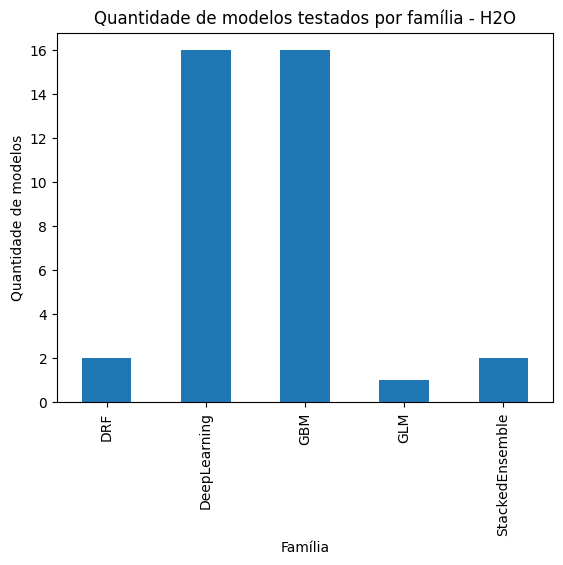

In [42]:
h2o = next((run for run in runs if run["framework"] == "h2o"), None)

if h2o is None:
    print("Nenhuma run H2O encontrada.")
else:
    metadata = h2o.get("metadata", {}) or {}
    best_model = h2o.get("best_model", {}) or {}
    search_history = h2o.get("search_history", pd.DataFrame())

    print("Resumo H2O AutoML")
    display(pd.DataFrame([{
        "framework": "H2O AutoML",
        "run_id": h2o.get("run_id"),
        "preset": metadata.get("preset"),
        "métrica": metadata.get("optimization_metric"),
        "tempo_total_min": metadata.get("training_time_seconds") / 60,
        "total_modelos_testados": len(search_history),
        "melhor_modelo": best_model.get("model_name"),
        "familia_melhor_modelo": best_model.get("model_family"),
        "score": (best_model.get("score") or {}).get("value"),
    }]))

    if not search_history.empty:
        print("Top 10 modelos do leaderboard")
        cols = [c for c in [
            "model_id", "algo", "rmse", "mse", "mae",
            "training_time_ms", "predict_time_per_row_ms"
        ] if c in search_history.columns]

        sort_col = "rmse" if "rmse" in search_history.columns else None
        top_h2o = search_history.sort_values(sort_col).head(10) if sort_col else search_history.head(10)
        display(top_h2o[cols])

        if "algo" in search_history.columns:
            print("Resumo por família de modelo")

            agg_dict = {
                "model_id": "count"
            }

            if "rmse" in search_history.columns:
                agg_dict["rmse"] = ["min", "mean"]

            if "training_time_ms" in search_history.columns:
                agg_dict["training_time_ms"] = "mean"

            resumo_familias = search_history.groupby("algo").agg(agg_dict)

            resumo_familias.columns = [
                "_".join(col).strip("_") if isinstance(col, tuple) else col
                for col in resumo_familias.columns
            ]

            resumo_familias = resumo_familias.rename(columns={
                "model_id_count": "qtd_modelos",
                "rmse_min": "melhor_rmse",
                "rmse_mean": "rmse_medio",
                "training_time_ms_mean": "tempo_medio_treino_ms"
            }).reset_index()

            display(resumo_familias.sort_values("melhor_rmse" if "melhor_rmse" in resumo_familias.columns else "qtd_modelos"))

            if "tempo_medio_treino_ms" in resumo_familias.columns:
                resumo_familias["tempo_medio_treino_s"] = resumo_familias["tempo_medio_treino_ms"] / 1000

            resumo_familias.plot(
                x="algo",
                y="qtd_modelos",
                kind="bar",
                legend=False,
                title="Quantidade de modelos testados por família - H2O"
            )
            plt.xlabel("Família")
            plt.ylabel("Quantidade de modelos")
            plt.show()

In [43]:
h2o = next((run for run in runs if run["framework"] == "h2o"), None)
h2o["search_history"].head()
h2o["search_history"].shape

(37, 9)

## Analise TPOT

O TPOT usa uma busca evolutiva baseada em pipelines. A cada geracao, novos individuos/pipelines sao avaliados a partir de operadores como mutacao e cruzamento. Isso pode ser observado nas colunas `Generation`, `Parents` e `Variation_Function`. O melhor pipeline e escolhido com base na metrica definida no preset.

In [48]:
# ============================================
# ANÁLISE TPOT RECUPERADA DO REPORT QUEBRADO
# ============================================

import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Markdown


def extrair_search_history_quebrado(tpot_data):
    report = tpot_data.get("report", {}) or {}
    raw = report.get("search_history")

    if raw is None:
        raw = tpot_data.get("search_history")

    if isinstance(raw, pd.DataFrame):
        return raw.copy()

    if isinstance(raw, list):
        return pd.DataFrame(raw)

    if not isinstance(raw, str):
        return pd.DataFrame()

    linhas = []

    for linha in raw.splitlines():
        linha = linha.rstrip()

        if not linha.strip():
            continue
        if linha.strip().startswith("["):
            continue
        if linha.strip().startswith(".."):
            continue
        if "root_mean_squared_error" in linha and "Parents" in linha:
            continue

        padrao = re.match(
            r"^\s*(\d+)\s+(-?\d+(?:\.\d+)?)\s+(NaN|\([^)]+\))\s+(.*?)\s+\.\.\.\s+(.*?)\s+(NaN|-?\d+(?:\.\d+)?)\s+(.*)$",
            linha
        )

        if not padrao:
            continue

        indice, score, parents, variation, eval_error, pareto, instance = padrao.groups()

        linhas.append({
            "indice": int(indice),
            "root_mean_squared_error": float(score),
            "RMSE": abs(float(score)),
            "Parents": None if parents == "NaN" else parents,
            "Variation_Function": None if variation.strip() == "NaN" else variation.strip(),
            "Eval_Error": eval_error.strip(),
            "Pareto_Front": None if pareto == "NaN" else float(pareto),
            "Instance": instance.strip(),
            "origem": "search_history_visivel"
        })

    return pd.DataFrame(linhas)


def extrair_melhor_do_score_value(tpot_data):
    best = tpot_data.get("best_model", {}) or {}
    score = best.get("score", {}) or {}
    texto = score.get("value")

    if not isinstance(texto, str):
        return pd.DataFrame()

    def extrair_numero(campo):
        padrao = re.search(rf"{campo}\s+(-?\d+(?:\.\d+)?)", texto)
        return float(padrao.group(1)) if padrao else None

    def extrair_texto(campo):
        padrao = re.search(rf"{campo}\s+(.+)", texto)
        return padrao.group(1).strip() if padrao else None

    rmse_neg = extrair_numero("root_mean_squared_error")
    generation = extrair_numero("Generation")

    name_match = re.search(r"Name:\s*(\d+)", texto)
    indice = int(name_match.group(1)) if name_match else None

    parents = extrair_texto("Parents")
    variation = extrair_texto("Variation_Function")
    pareto = extrair_numero("Pareto_Front")
    instance = extrair_texto("Instance")

    if rmse_neg is None:
        return pd.DataFrame()

    return pd.DataFrame([{
        "indice": indice,
        "Generation": generation,
        "root_mean_squared_error": rmse_neg,
        "RMSE": abs(rmse_neg),
        "Parents": parents,
        "Variation_Function": variation,
        "Pareto_Front": pareto,
        "Instance": instance,
        "origem": "melhor_individuo"
    }])


def resumir_pipeline_instance(texto, limite=120):
    if pd.isna(texto):
        return None

    texto = str(texto)

    nomes = re.findall(
        r"(StandardScaler|MinMaxScaler|Normalizer|RobustScaler|MaxAbsScaler|"
        r"SelectFromModel|SelectPercentile|SelectFwe|RFE|VarianceThreshold|"
        r"FeatureUnion|Binarizer|ColumnOrdinalEncoder|EstimatorTransformer|"
        r"LGBMRegressor|ExtraTreesRegressor|HistGradientBoostingRegressor|"
        r"RandomForestRegressor|XGBRegressor|Passthrough)",
        texto
    )

    nomes = list(dict.fromkeys(nomes))

    if nomes:
        return " → ".join(nomes[:8])

    return texto[:limite] + ("..." if len(texto) > limite else "")


def resumir_etapas_pipeline_final(best_model):
    hyper = best_model.get("hyperparameters", {}) or {}
    steps = hyper.get("steps", [])

    linhas = []

    for i, step in enumerate(steps, start=1):
        nome, objeto = step

        linhas.append({
            "ordem": i,
            "etapa": nome,
            "resumo": resumir_pipeline_instance(objeto),
            "detalhe": objeto
        })

    return pd.DataFrame(linhas)


# ============================================
# EXECUÇÃO
# ============================================

tpot_data = next((r for r in runs if r["framework"] == "tpot"), None)

if tpot_data is None:
    print("Sem run TPOT.")
else:
    metadata = tpot_data.get("metadata", {}) or {}
    best = tpot_data.get("best_model", {}) or {}

    hist_visivel = extrair_search_history_quebrado(tpot_data)
    melhor_df = extrair_melhor_do_score_value(tpot_data)

    display(Markdown("## Análise TPOT"))

    # -----------------------------
    # 1. Melhor resultado
    # -----------------------------

    if melhor_df.empty:
        print("Não consegui recuperar o melhor indivíduo pelo best_model['score']['value'].")
    else:
        melhor = melhor_df.iloc[0]

        display(Markdown("### 1. Melhor resultado encontrado"))

        resumo = pd.DataFrame([{
            "run_id": metadata.get("run_id"),
            "preset": metadata.get("preset"),
            "métrica": metadata.get("optimization_metric"),
            "tempo_total_min": metadata.get("training_time_seconds") / 60,
            "melhor_indice": melhor.get("indice"),
            "geracao_do_melhor": melhor.get("Generation"),
            "melhor_RMSE": melhor.get("RMSE"),
            "score_original_negativo": melhor.get("root_mean_squared_error"),
            "parents": melhor.get("Parents"),
            "operador": melhor.get("Variation_Function"),
            "familia_final": best.get("model_family"),
        }])

        display(resumo)

    # -----------------------------
    # 2. Pipeline final em etapas
    # -----------------------------

    display(Markdown("### 2. Pipeline final em etapas"))

    print("Família do melhor modelo:", best.get("model_family"))

    etapas = resumir_etapas_pipeline_final(best)

    if etapas.empty:
        print("Não encontrei etapas estruturadas no best_model.")
    else:
        display(Markdown("#### Detalhes completos das etapas"))
        display(etapas)

## Análise TPOT

### 1. Melhor resultado encontrado

,run_id,preset,métrica,tempo_total_min,melhor_indice,geracao_do_melhor,melhor_RMSE,score_original_negativo,parents,operador,familia_final
0,20260430T150932Z,medium,neg_root_mean_squared_error,25.756541,172,8.0,4.939356,-4.939356,"(123, 123)",ind_mutate,LGBMRegressor


### 2. Pipeline final em etapas

Família do melhor modelo: LGBMRegressor


#### Detalhes completos das etapas

,ordem,etapa,resumo,detalhe
0,1,standardscaler,StandardScaler,StandardScaler()
1,2,selectfrommodel,SelectFromModel → ExtraTreesRegressor,"SelectFromModel(estimator=ExtraTreesRegressor(bootstrap=np.False_,\n cr..."
2,3,featureunion-1,FeatureUnion → ColumnOrdinalEncoder → Passthrough,"FeatureUnion(transformer_list=[('featureunion',\n FeatureUnion(transformer_list=[('co..."
3,4,featureunion-2,FeatureUnion → EstimatorTransformer → LGBMRegressor → Passthrough,"FeatureUnion(transformer_list=[('featureunion',\n FeatureUnion(transformer_list=[('es..."
4,5,lgbmregressor,LGBMRegressor,"LGBMRegressor(boosting_type=np.str_('gbdt'), max_depth=10, n_estimators=93,\n n_jobs=1, num_leaves=217,..."


StandardScaler: padroniza os dados, colocando as variáveis na mesma escala para ajudar o modelo a aprender melhor.
SelectFromModel com ExtraTreesRegressor: escolhe automaticamente as variáveis mais importantes usando um modelo de árvores.
FeatureUnion com ColumnOrdinalEncoder e Passthrough: transforma colunas categóricas em números e mantém outras colunas sem alteração.
FeatureUnion com EstimatorTransformer e LGBMRegressor: cria novas características usando previsões de um modelo LightGBM e junta isso com os dados originais.
LGBMRegressor: modelo final de regressão que aprende padrões nos dados para prever valores numéricos.